<a href="https://colab.research.google.com/github/ML4SCI/DeepLearnHackathon/blob/main/HiggsBosonClassificationChallenge/higgs_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Higgs Classification Challenge

**Background:** High-energy collisions at the Large Hadron Collider (LHC) <br> produce particles that interact with particle detectors. One important task is <br>
to classify different types of collisions based on their physics content,<br> allowing physicists to find patterns in the data and to potentially unravel new <br> discoveries.

**Problem statement:** The discovery of the Higgs boson by CMS and ATLAS <br>
Collaborations was announced at CERN in 2012. In this challenge, we will use <br>
machine learning to classify events containing Higgs bosons from the background <br>
events which do not contain Higgs bosons.

**Dataset:** The dataset is hosted by the Center for Machine Learning  <br>
and Intelligent Systems at University of California, Irvine. <br>
The dataset can be found on the [UCI Machine learning Repository](https://archive.ics.uci.edu/ml/datasets/HIGGS)

**Description:** The dataset consists of a total of 11 million labeled samples <br>
of Higgs and background events produced by Monte Carlo simulations. Each sample <br>
consists of 28 features. The first 21 features are kinematic properties <br>
of the events. The last seven are functions of the first 21. The data labels <br>
are 1 for signal (an event with Higgs bosons) and 0 for background (an event <br>
without Higgs bosons).

**Steps to load the training dataset**   
If you are having problems with this part in Colab, you can also download the file manually and put it in your Google Drive. You can then [connect your Google Drive to Colab](https://towardsdatascience.com/different-ways-to-connect-google-drive-to-a-google-colab-notebook-pt-1-de03433d2f7a)

1. Download the dataset from the UCI website.

In [31]:
from oauthlib.oauth2.rfc8628.clients import device
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz

--2026-07-14 19:58:03--  https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘HIGGS.csv.gz’

HIGGS.csv.gz            [       <=>          ]  61.52M  7.03MB/s               ^C


2. Unzip the dataset folder

In [ ]:
!gzip -d HIGGS.csv.gz

In [ ]:
%%sql


In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
np.random.seed(1337)  # for reproducibility
import matplotlib.pyplot as plt

**Load the file using pandas library**

In [4]:
data = pd.read_csv('./HIGGS.csv', header=None)

The first column is the labels (y). The other columns are all of our inputs (X).

The above dataset is a pandas dataframe. We can access the data using iloc. <br>
After that, we can turn it into a numpy array if we want or leave it as a <br>
pandas dataframe. **Use whatever you feel most comfortable with**.


In [5]:
X = data.iloc[:,1:]
y = data.iloc[:,0]
#X = X.to_numpy(dtype=float) #Convert pandas dataframe to numpy array (optional)
#y = y.to_numpy(dtype=int)   #Convert pandas dataframe to numpy array (optional)

In [5]:
print(X.shape)
print(y.shape)

(11000000, 28)
(11000000,)


In [ ]:
%%sql


To generate the following examples we used a smaller dataset containing only <br>
10,000 events. You may want to do something similar while getting your code <br>
set up but you should eventually use the full dataset.

**For final hackathon task submissions you must use the full test set.**

In [6]:
X_small = X[:11000] # X[:11000]
y_small = y[:11000] # X[:11000]

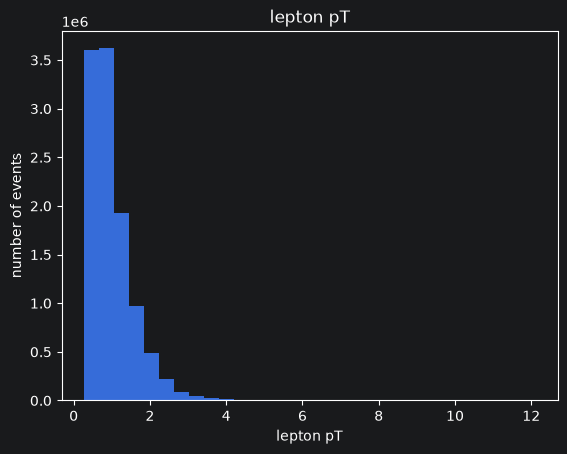

In [7]:
plt.hist(X.iloc[:,0], bins=30)
plt.title("lepton pT")
plt.xlabel("lepton pT")
plt.ylabel("number of events")
plt.show()

Next we can split our data into 9mil training data, 1mil validation data, 1mil <br>
test data.

For the rest of this hackathon, use `X_train`, `X_val`, `X_test` as input <br>
data and `y_train`, `y_val`, `y_test` as output data.

In [7]:
X_train, X_val1, y_train, y_val1 = train_test_split(X, y, test_size=0.0909090909, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val1, y_val1, test_size=0.5, random_state=42)

X_train_small, X_val1_small, y_train_small, y_val1_small = train_test_split(X_small, y_small, test_size=0.0909090909, random_state=42)
X_val_small, X_test_small, y_val_small, y_test_small = train_test_split(X_val1_small, y_val1_small, test_size=0.5, random_state=42)

In [66]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(10000000, 28)
(500000, 28)
(500000, 28)
(10000000,)
(500000,)
(500000,)


## **REMINDER: Use the Higgs dataset provided above for the Hackathon**

## Hackathon Task 1:

Data: `X_train`

Generate histograms of the different variables in `X_train` with proper axis <br>
labels and titles.

Detailed information on what each feature column is can be found in <br> *Attribute Information* section on the [UCI Machine learning Repository](https://archive.ics.uci.edu/ml/datasets/HIGGS). <br>
For further information, refer to the [paper](https://www.nature.com/articles/ncomms5308) by Baldi et. al

**Hint:** The first item is lepton pT.

The following may be helpful:

`names = ["lepton pT", "lepton eta", "lepton phi", "missing energy magnitude",` <br>
`"missing energy phi", "jet 1 pt", "jet 1 eta", "jet 1 phi", "jet 1 b-tag",` <br>
`"jet 2 pt", "jet 2 eta","jet 2 phi", "jet 2 b-tag", "jet 3 pt", "jet 3 eta",` <br>
`"jet 3 phi", "jet 3 b-tag", "jet 4 pt", "jet 4 eta", "jet 4 phi", "jet 4 b-tag",`<br>` "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"]`

`for index, name in enumerate(names):`

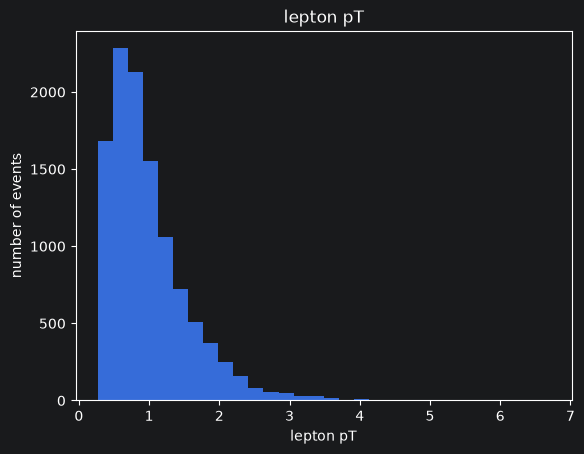

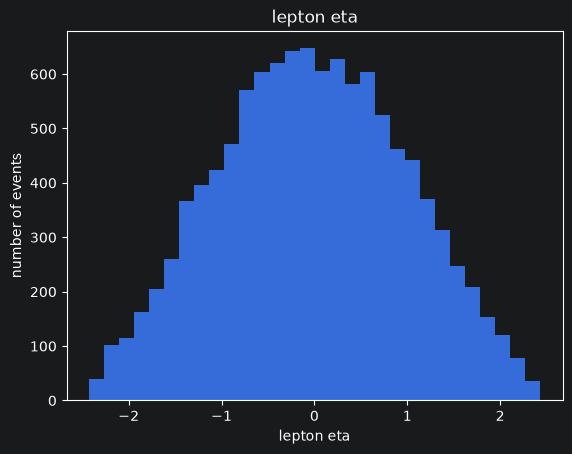

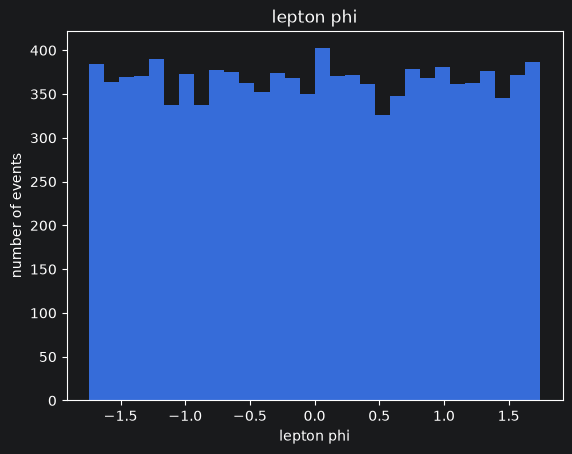

In [16]:
names = ["lepton pT", "lepton eta", "lepton phi", "missing energy magnitude","missing energy phi", "jet 1 pt", "jet 1 eta", "jet 1 phi", "jet 1 b-tag","jet 2 pt", "jet 2 eta","jet 2 phi", "jet 2 b-tag", "jet 3 pt", "jet 3 eta","jet 3 phi", "jet 3 b-tag", "jet 4 pt", "jet 4 eta", "jet 4 phi", "jet 4 b-tag","m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"];

for index in range(len(names)): # range(3):
# for index, name in enumerate(names):
    name = names[index]
    plt.hist(X.iloc[:,index], bins=30)
    plt.title(name)
    plt.xlabel(name)
    plt.ylabel("number of events")
    plt.show()

## Hackathon Task 2:

Data: `X_train`, `y_train`, `X_val`, `y_val`

Train a model by fitting it to the training data. Use at least one metric <br>
such as roc_auc_score, accuracy, etc. to analyze the model's performance on the <br>
validation data. Using that performance metric, optimize or improve your model. <br>
It should be clear from your notebook how you perform this optimization.

In [9]:
import optuna
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

# Turn off logging if needed
# lgb.register_logger(None)

# We name it whatever we want and clearly declare the incoming types
def optimize_lgbm_model(trial: optuna.trial.Trial, _X: pd.DataFrame, _y: pd.Series) -> float:

    # The 'trial' object methods return standard primitives
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 30, 300),
        'random_state': 42,
        'verbose': -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucpr_scores = []

    # X and y are explicitly typed as Pandas DataFrames and Series
    for train_idx, val_idx in cv.split(_X, _y):
        X_tr, X_val = _X.iloc[train_idx], _X.iloc[val_idx]
        y_tr, y_val = _y.iloc[train_idx], _y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)

        probs = model.predict_proba(X_val)[:, 1]
        aucpr_scores.append(average_precision_score(y_val, probs))

    # Optuna expects a single float returned to score the trial
    return float(np.mean(aucpr_scores))

# --- Running the study ---
study = optuna.create_study(direction='maximize')

# Pass the custom function through the lambda wrapper normally
study.optimize(lambda t: optimize_lgbm_model(t, X_train_small, y_train_small), n_trials=20)

for key, value in study.best_params.items():
    print(f"  {key}: {value}")

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-15 19:45:51,076] A new study created in memory with name: no-name-3e04d5e4-8f04-41b5-80c4-06653e5ec518
[I 2026-07-15 19:45:51,350] Trial 0 finished with value: 0.833242511094817 and parameters: {'n_estimators': 138, 'max_depth': 3, 'learning_rate': 0.07367358013211801, 'num_leaves': 95}. Best is trial 0 with value: 0.833242511094817.
[I 2026-07-15 19:45:52,046] Trial 1 finished with value: 0.8984690136574018 and parameters: {'n_estimators': 201, 'max_depth': 5, 'learning_rate': 0.06456738736897928, 'num_leaves': 39}. Best is trial 1 with value: 0.8984690136574018.
[I 2026-07-15 19:45:57,399] Trial 2 finished with value: 0.9382437316670135 and parameters: {'n_estimators': 283, 'max_depth': 11, 'learning_rate': 0.014542598057253601, 'num_leav

  n_estimators: 348
  max_depth: 10
  learning_rate: 0.12065288554677397
  num_leaves: 176


In [49]:
# NOTE: this appears less effective and much slower - skipping over but figured i'd leave it as an example for other tasks
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# TabNet requires a specific array shape and prefers unscaled or lightly scaled data
clf = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax'
)

# Fit the model
clf.fit(
    X_train=X_train.values, y_train=y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    eval_name=['train'],
    eval_metric=['auc'],
    max_epochs=12,
    patience=5,
    batch_size=4096,
    virtual_batch_size=512
)

/home/dylan/code/DeepLearnHackathon/HiggsBosonClassificationChallenge/.venv/lib/python3.14/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.70854 | train_auc: 0.58732 |  0:00:03s
epoch 1  | loss: 0.59885 | train_auc: 0.71623 |  0:00:06s
epoch 2  | loss: 0.58332 | train_auc: 0.75949 |  0:00:09s
epoch 3  | loss: 0.57127 | train_auc: 0.77632 |  0:00:12s
epoch 4  | loss: 0.56356 | train_auc: 0.78214 |  0:00:15s
epoch 5  | loss: 0.55855 | train_auc: 0.78653 |  0:00:19s
epoch 6  | loss: 0.55936 | train_auc: 0.78433 |  0:00:22s
epoch 7  | loss: 0.55601 | train_auc: 0.78994 |  0:00:25s
epoch 8  | loss: 0.55327 | train_auc: 0.789   |  0:00:28s
epoch 9  | loss: 0.55527 | train_auc: 0.78858 |  0:00:31s
epoch 10 | loss: 0.54815 | train_auc: 0.79661 |  0:00:34s
epoch 11 | loss: 0.54188 | train_auc: 0.79573 |  0:00:38s
Stop training because you reached max_epochs = 12 with best_epoch = 10 and best_train_auc = 0.79661


/home/dylan/code/DeepLearnHackathon/HiggsBosonClassificationChallenge/.venv/lib/python3.14/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.71      0.68      0.69     10634
         1.0       0.73      0.75      0.74     12094

    accuracy                           0.72     22728
   macro avg       0.72      0.72      0.72     22728
weighted avg       0.72      0.72      0.72     22728

--- Confusion Matrix ---


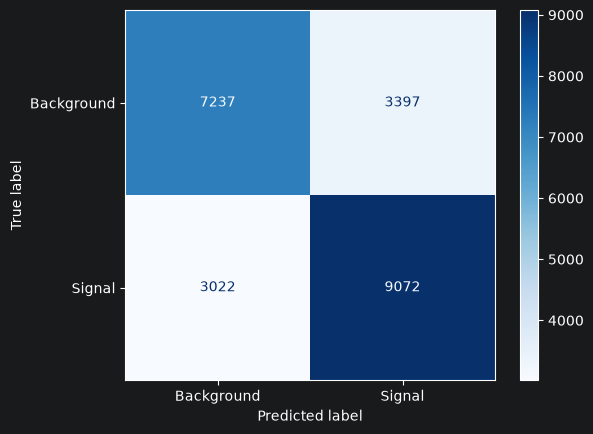

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Fix: Convert X_test to a numpy array using .values
predictions = clf.predict(X_test.values)

# 1. Print the text report
print("--- Classification Report ---")
print(classification_report(y_test, predictions))

# 2. Plot the Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background', 'Signal'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [16]:
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV

# Use Optuna best params (tests as better than smaller)
base_model = lgb.LGBMClassifier(
    **study.best_params,
    # is_unbalance=True,
    # metric='auc',
    # force_row_wise=True,
    force_col_wise=True,
    random_state=42,
)

# scaled_model = CalibratedClassifierCV(estimator=base_model, method='isotonic', cv=5)

# scaled_model.fit(X_train, y_train)

base_model.fit(X_train, y_train)

print("Training complete successfully!")

Training complete successfully!


In [24]:
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV


# NOTE turns out optimising using a smaller dataset doesn't extrapolate to a larger dataset well
base_model = lgb.LGBMClassifier(
    # is_unbalance=True,
    # metric='auc',
    # force_row_wise=True,
    # objective = 'binary',
    # metric = 'auc',
    # boosting_type = 'gbdt',
    n_estimators=5000,
    learning_rate=0.1,
    num_leaves=255,
    force_col_wise=True,
    # i think we need this to match the disposal advantage shown in the original paper..
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    random_state=42,
    n_jobs=-1,
    # objective=
)


# scaled_model = CalibratedClassifierCV(estimator=base_model, method='isotonic', cv=5)

# scaled_model.fit(X_train, y_train)

base_model.fit(X_train, y_train,
               eval_set=[(X_val, y_val)],
               eval_metric='auc',
               callbacks=[
                    lgb.early_stopping(stopping_rounds=50),
                    lgb.log_evaluation(period=50)
               ])

print("Training complete successfully!")

[LightGBM] [Info] Number of positive: 5299480, number of negative: 4700520
[LightGBM] [Info] Total Bins 6132
[LightGBM] [Info] Number of data points in the train set: 10000000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529948 -> initscore=0.119936
[LightGBM] [Info] Start training from score 0.119936
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.811791	valid_0's binary_logloss: 0.53004
[100]	valid_0's auc: 0.821632	valid_0's binary_logloss: 0.515306
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.821632	valid_0's binary_logloss: 0.515306
Training complete successfully!


In [10]:
import lightgbm as lgb

# 1. Define how you want the learning rate to drop based on the tree number
def learning_rate_decay(current_tree):
    if current_tree < 300:
        return 0.2      # Sprint to 0.84 AUC
    elif current_tree < 600:
        return 0.15      # Jog to 0.86 AUC
    elif current_tree < 2000:
        return 0.1
    elif current_tree < 2500:
        return 0.05
    else:
        return 0.01

# 2. Remove learning_rate from your params dictionary
params = {
    'objective': 'binary',
    'metric': 'auc',
    # 'max_bin': 63,
    'num_leaves': 255,
    # 'learning_rate': 0.1, # now dynamic
    'n_jobs': -1,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'subsample_freq': 1,
    'random_state': 42,
    'device': 'gpu',
}

# create training dataset
train_data = lgb.Dataset(data=X_train, label=y_train)
# important-link the validation dataset so the binning matches!
valid_data = lgb.Dataset(data=X_val, label=y_val, reference=train_data)

lgb_native_model = lgb.train(
    params,
    train_data,
    num_boost_round=100000,
    valid_sets=[valid_data],
    callbacks=[
        # This will inject the new learning rate at the start of every tree
        lgb.reset_parameter(learning_rate=learning_rate_decay),
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=50),
    ]
)

print("Training complete successfully!")

[LightGBM] [Info] Number of positive: 5299480, number of negative: 4700520
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 6132
[LightGBM] [Info] Number of data points in the train set: 10000000, number of used features: 28
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5070 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 27 dense feature groups (267.03 MB) transferred to GPU in 0.147327 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.529948 -> initscore=0.119936
[LightGBM] [Info] Start training from score 0.119936
Training until validation scores don't improve for 20 rounds
[50]	valid_0's auc: 0.830147
[100]	valid_0's auc: 0.837635
[150]	valid_0's auc: 0.840144
[200]	valid_0's auc: 0.841184
[250]	valid_0's auc: 0.842262
[300]	valid_0's auc: 0.842987
[350]	valid_0's au

In [38]:
import lightgbm as lgb

# Same as above! thought it was faster but it turns out i was just reporting on fewer rounds..
# Identical AUC per round number, same speed, prefer this method sig

# Above seems to use the GPU param correctly so train() is identical but faster

# 1. Define how you want the learning rate to drop based on the tree number
def learning_rate_decay(current_tree):
    if current_tree < 300:
        return 0.2      # Sprint to 0.84 AUC
    elif current_tree < 600:
        return 0.15      # Jog to 0.86 AUC
    elif current_tree < 2000:
        return 0.1
    elif current_tree < 3000:
        return 0.05
    else:
        return 0.005     # Micro-adjustments to squeeze out the final 0.88

# NOTE turns out optimising using a smaller dataset doesn't extrapolate to a larger dataset well
base_model = lgb.LGBMClassifier(
    # is_unbalance=True,
    # metric='auc',
    # force_row_wise=True,
    # objective = 'binary',
    # metric = 'auc',
    # boosting_type = 'gbdt',
    n_estimators=10000,
    # learning_rate=0.1,
    num_leaves=255,
    force_col_wise=True,
    # i think we need this to match the disposal advantage shown in the original paper..
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    random_state=42,
    n_jobs=-1,
    # device='gpu'
    # objective=
)


# scaled_model = CalibratedClassifierCV(estimator=base_model, method='isotonic', cv=5)

# scaled_model.fit(X_train, y_train)

base_model.fit(X_train, y_train,
               eval_set=[(X_val, y_val)],
               eval_metric='auc',
               callbacks=[
                    lgb.reset_parameter(learning_rate=learning_rate_decay),
                    lgb.early_stopping(stopping_rounds=20),
                    lgb.log_evaluation(period=50)
               ])

print("Training complete successfully!")

Training until validation scores don't improve for 20 rounds
[50]	valid_0's auc: 0.830074	valid_0's binary_logloss: 0.504064
[100]	valid_0's auc: 0.837555	valid_0's binary_logloss: 0.493787


KeyboardInterrupt: 

## Hackathon Task 3:

Data: `X_test`, `y_test`

**Note: The test data should be used only for final performance evaluation.** <br>
**Validation data can be used to tune your model but test data should not be** <br>
**used for model tuning.**

Without having done any optimization using the testing data set, analyze the <br>
performance of the model on the testing data. Your analysis should include <br> [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html), a ROC curve plot, and at least one other plot of your choice<br>
such as precision-recall curves, confusion matrix, etc.


In [11]:
# Copied from below

def plot_roc_curve(_y_test, _y_hat):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(_y_test, _y_hat)
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Higgs event signal')
    plt.legend()
    plt.show()
    print("AUC:", roc_auc)

              precision    recall  f1-score   support

         0.0       0.73      0.72      0.72    235016
         1.0       0.75      0.76      0.76    264984

    accuracy                           0.74    500000
   macro avg       0.74      0.74      0.74    500000
weighted avg       0.74      0.74      0.74    500000



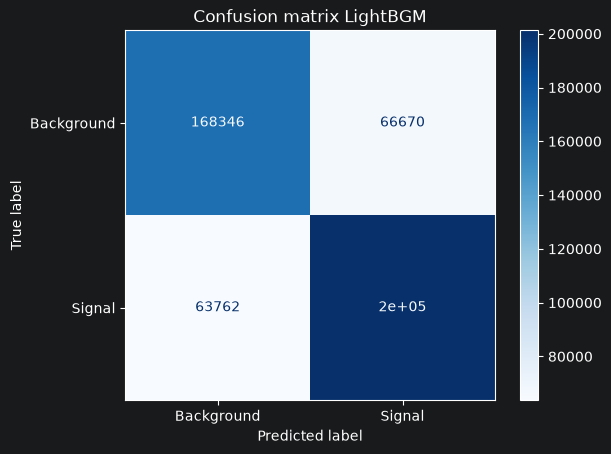

LightGBM ROC 0.7378456689035313


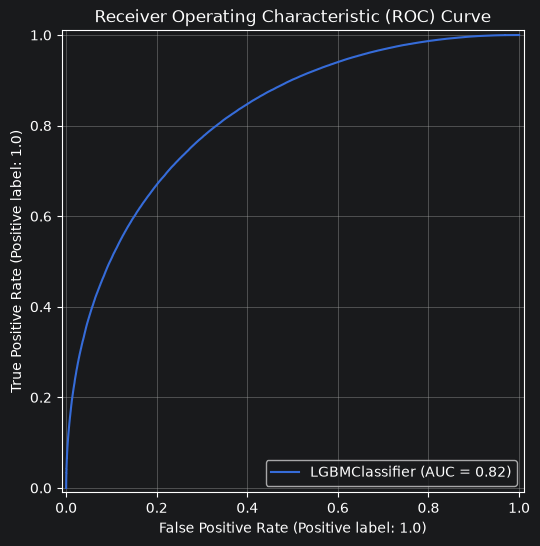

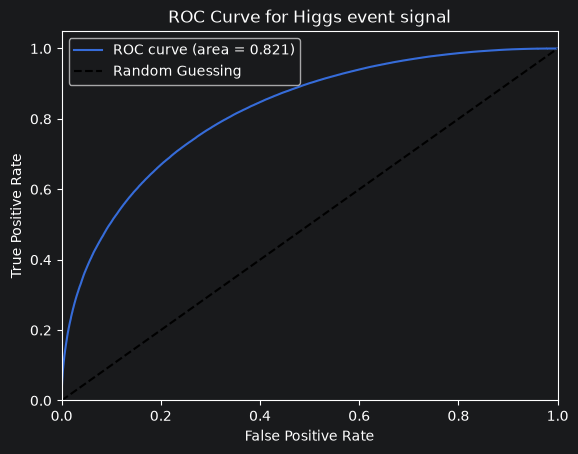

AUC: 0.8205463132690403


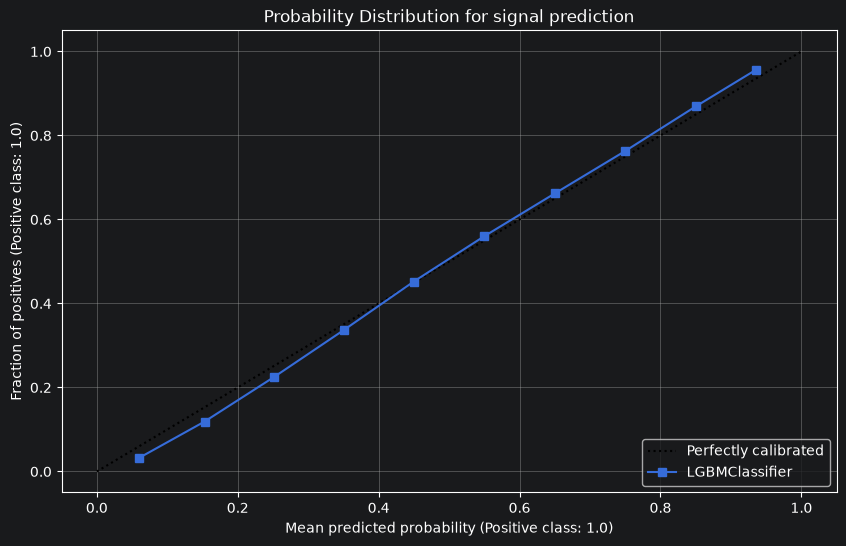

In [25]:
# Works for .fit() output - predictions are binary

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, auc, roc_curve, mean_absolute_error, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.calibration import CalibrationDisplay

# Generate predictions on the test data
predictions = base_model.predict(X_test)
print(classification_report(y_test, predictions))

# cm = confusion_matrix(y_test, predictions)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background', 'Signal'])
# disp.plot(cmap=plt.cm.Blues)
# plt.show()

# better!
ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['Background', 'Signal'], cmap=plt.cm.Blues)
plt.title("Confusion matrix LightBGM")
plt.show()

# last model
# tabGroupRoc = roc_auc_score(y_test, clf.predict(X_test.values))
# print(f"Tab group model ROC {tabGroupRoc:3}")
# this model
lgbmRoc = roc_auc_score(y_test, predictions)
print(f"LightGBM ROC {lgbmRoc:3}")
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(base_model, X_test, y_test, ax=ax)
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.grid(True)
plt.show()

y_hat = base_model.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_hat)

# This will automatically compute the 10 bins from your report and plot them
fig, ax = plt.subplots(figsize=(10, 6))
CalibrationDisplay.from_estimator(base_model, X_test, y_test, n_bins=10, ax=ax)

plt.title("Probability Distribution for signal prediction")
plt.grid(True)
plt.show()


              precision    recall  f1-score   support

         0.0       0.76      0.74      0.75    235016
         1.0       0.77      0.79      0.78    264984

    accuracy                           0.77    500000
   macro avg       0.77      0.77      0.77    500000
weighted avg       0.77      0.77      0.77    500000



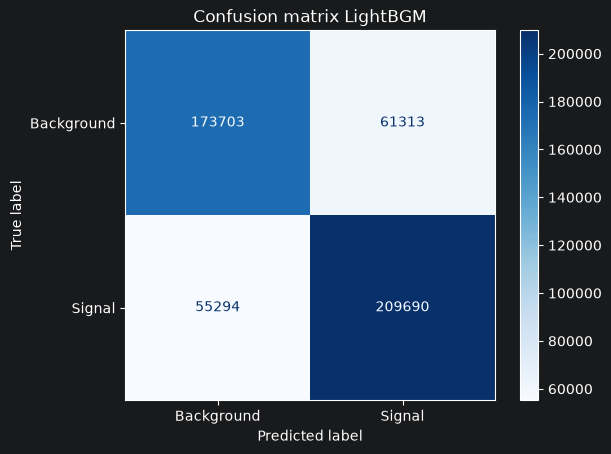

LightGBM ROC 0.7652210884909534


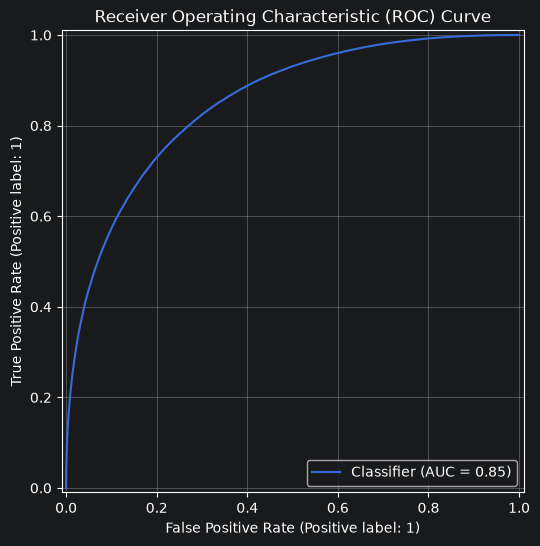

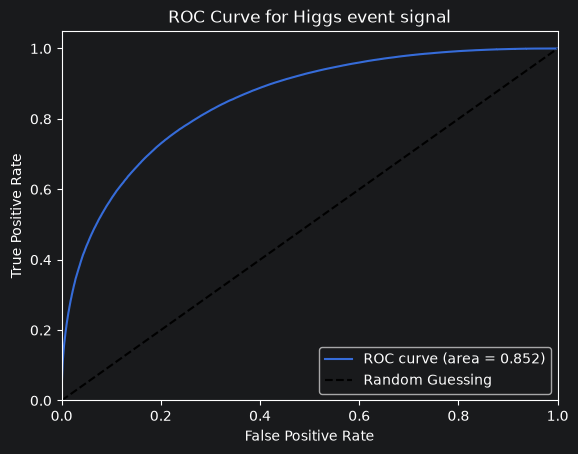

AUC: 0.8516373701337857


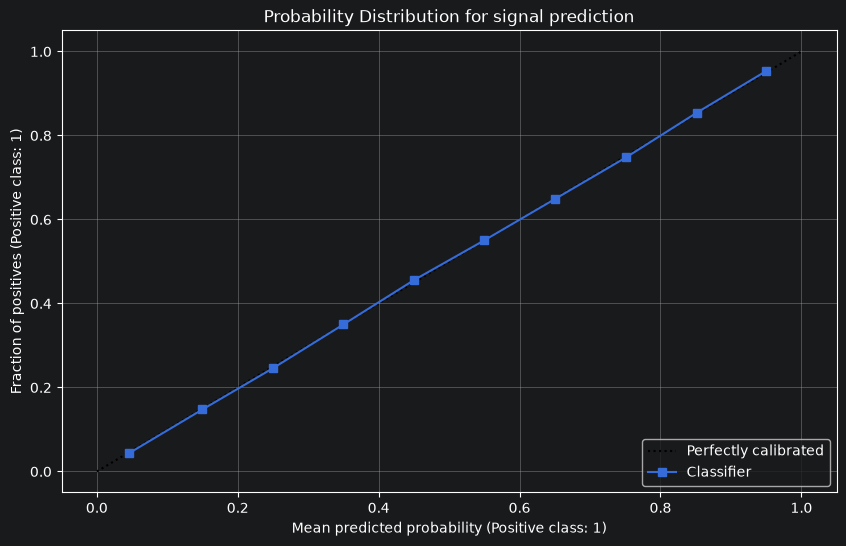

In [21]:
# Works for .train() native output - need to use that for GPU
# predictions are fp scores

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, auc, roc_curve, mean_absolute_error, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.calibration import CalibrationDisplay

# Generate predictions on the test data
prob = lgb_native_model.predict(X_test)
# get binary predictions for classification report
predictions = (prob >= 0.5).astype(int)
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['Background', 'Signal'], cmap=plt.cm.Blues)
plt.title("Confusion matrix LightBGM")
plt.show()

# last model
# tabGroupRoc = roc_auc_score(y_test, clf.predict(X_test.values))
# print(f"Tab group model ROC {tabGroupRoc:3}")
# this model
lgbmRoc = roc_auc_score(y_test, predictions)
print(f"LightGBM ROC {lgbmRoc:3}")
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, prob, ax=ax)
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.grid(True)
plt.show()

plot_roc_curve(y_test, prob)

# This will automatically compute the 10 bins from your report and plot them
fig, ax = plt.subplots(figsize=(10, 6))
CalibrationDisplay.from_predictions(y_test, prob, n_bins=10, ax=ax)

plt.title("Probability Distribution for signal prediction")
plt.grid(True)
plt.show()


# Deliverables:

-Fill out the pre- and post- hackathon surveys.
**Reminder: The hackathon tasks should be done using the Higgs dataset.** <br>
A pdf of the notebook with all three hackathon tasks completed. <br>
A copy of your colab/jupyter notebook (.ipynb and pdf) with all three hackathon tasks completed. <br>


File name convention: Try to give your submission files descriptive names, e.g. "Higgs_Yourname.pdf" and  <br>
"Higgs_Yourname.ipynb".


# Examples

The examples below use a different dataset (breast cancer diagnosis dataset) than what is provided above. Please use the Higgs data set for the hackathon.

Note: The following examples are meant to provide a starting point. You are encouraged to get creative. Feel free to look back to earlier assignments for inspiration and code examples.

## Decision Tree Example

In [86]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [87]:
dataset = load_breast_cancer() #Use the Higgs dataset for the hackathon
X = dataset["data"]
y = dataset["target"]

In [88]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [90]:
classifier = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    random_state=42
)

In [91]:
classifier.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](200,)","[0.08,0.16,0.17,...,0.33,0.36,0.44]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](200,)","[2.51,1.69,1.61,...,0.73,0.59,0.25]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](30,)","[0. ,0.08,0. ,...,0.07,0.06,0. ]"


In [92]:
predictions = classifier.predict(X_test)

In [93]:
y_hat = classifier.predict_proba(X_test)[:, 1]

In [94]:
confusion_matrix(y_test, predictions)

array([[ 62,   1],
       [  2, 106]])

In [95]:
accuracy_score(y_test, predictions)

0.9824561403508771

In [21]:
from sklearn.metrics import roc_curve, auc

In [19]:
def plot_roc_curve(y_test, y_hat):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_hat)
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Breast Cancer Classification')
    plt.legend()
    plt.show()
    print("AUC:", roc_auc)

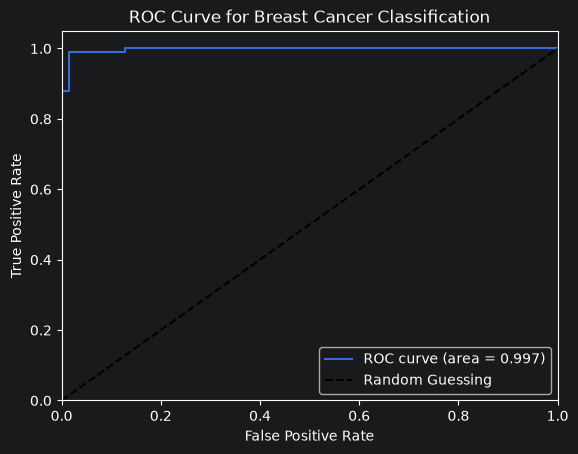

AUC: 0.9970605526161082


In [23]:
plot_roc_curve(y_test, y_hat)

## Basic Neural Network Example

In [97]:
from numpy import loadtxt
from torch import nn
import torch
from sklearn.datasets import load_breast_cancer
from torch.utils.data import Dataset, DataLoader
import sklearn.preprocessing

In [98]:
model_nn = nn.Sequential()
model_nn.append(nn.Linear(30, 64))
model_nn.append(nn.ReLU())
model_nn.append(nn.Linear(64, 8))
model_nn.append(nn.ReLU())
model_nn.append(nn.Linear(8, 1))
model_nn.append(nn.Flatten(start_dim=0))

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Flatten(start_dim=0, end_dim=-1)
)

In [99]:
dataset = load_breast_cancer() #Use the Higgs dataset for the hackathon
X = dataset["data"]
y = dataset["target"]

In [100]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [ ]:
# Note: The Higgs dataset is already pre-scaled so this step is not necessary
# in the actual hackathon
scaler = sklearn.preprocessing.StandardScaler()
scaler = scaler.fit(X)
X = scaler.transform(X)

In [ ]:
print(X.shape)
print(y.shape)

In [ ]:
X_train, X_test1, y_train, y_test1 = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test1, y_test1, test_size=0.5, random_state=42)

In [ ]:
class PytorchDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.copy()).float()
        self.y = torch.from_numpy(y.copy()).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
%%sql


In [ ]:
train_data = PytorchDataset(X_train, y_train)
val_data = PytorchDataset(X_val, y_val)
test_data = PytorchDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=5, shuffle=True)
test_loader = DataLoader(test_data, batch_size=5, shuffle=False)
val_loader = DataLoader(val_data, batch_size=5, shuffle=False)

In [ ]:
def train_and_validate(train_loader, val_loader, model, optimizer, criterion, metric, num_epochs):
    history = {
        'epoch': [],
        'train_loss': [],
        'train_metric': [],
        'val_loss': [],
        'val_metric': []
    }  # Initialize a dictionary to store epoch-wise results

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        epoch_loss = 0.0  # Initialize the epoch loss and metric values
        epoch_metric = 0.0

        # Training loop
        for X, y in train_loader:
            optimizer.zero_grad()  # Clear existing gradients
            outputs = model(X)  # Make predictions
            loss = criterion(outputs, y)  # Compute the loss
            loss.backward()  # Compute gradients
            optimizer.step()  # Update model parameters

            epoch_loss += loss.item()
            epoch_metric += metric(outputs, y)

        # Average training loss and metric
        epoch_loss /= len(train_loader)
        epoch_metric /= len(train_loader)

        # Validation loop
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():  # Disable gradient calculation
            val_loss = 0.0
            val_metric = 0.0
            for X_val, y_val in val_loader:
                outputs_val = model(X_val)  # Make predictions
                val_loss += criterion(outputs_val, y_val).item()  # Compute loss
                val_metric += metric(outputs_val, y_val)

            val_loss /= len(val_loader)
            val_metric /= len(val_loader)

        # Append epoch results to history
        history['epoch'].append(epoch_loss)
        history['train_loss'].append(epoch_loss)
        history['train_metric'].append(epoch_metric)
        history['val_loss'].append(val_loss)
        history['val_metric'].append(val_metric)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, '
              f'Train Metric: {epoch_metric:.4f}, Val Loss: {val_loss:.4f}, '
              f'Val Metric: {val_metric:.4f}')

    return history, model

In [ ]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

def accuracy_metric(target, pred):
    target = target.sigmoid().round()
    return torch.sum(pred == target).item() / len(pred)

In [ ]:
history, model_nn = train_and_validate(train_loader, val_loader, model_nn,
                                       optimizer=optimizer, criterion=criterion,
                                       metric=accuracy_metric, num_epochs=20)

In [ ]:
predictions = model_nn(test_loader.dataset.X).detach().numpy()

In [ ]:
def plot_roc_curve(y_test, y_hat):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_hat)
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Breast Cancer Classification')
    plt.legend()
    plt.show()
    print("AUC:", roc_auc)

In [ ]:
plot_roc_curve(y_test, predictions)

## Saving objects to drive

# Connecting notebook to google drive
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
# Saving serializable decision tree object
import pickle as pkl
with open("/content/drive/MyDrive/classifier.pkl", "wb") as f:
    pkl.dump(classifier, f)

In [ ]:
# Loading serializable decision tree object
with open("/content/drive/MyDrive/classifier.pkl", "rb") as f:
    new_classifier = pkl.load(f)

In [ ]:
# Saving neural network model weights using pytorch
torch.save(model_nn.state_dict(), "/content/drive/MyDrive/my_pytorch_model.h5")##Saving model weights

In [ ]:
# Loading neural network model weights using pytorch
new_model_nn = nn.Sequential()
new_model_nn.append(nn.Linear(30, 64))
new_model_nn.append(nn.ReLU())
new_model_nn.append(nn.Linear(64, 8))
new_model_nn.append(nn.ReLU())
new_model_nn.append(nn.Linear(8, 1))
new_model_nn.append(nn.Flatten(start_dim=0))

new_model_nn.load_state_dict(torch.load("/content/drive/MyDrive/my_pytorch_model.h5"))

In [ ]:
# Saving numpy array of predictions
np.save("/content/drive/MyDrive/predictions.npy", predictions)

In [ ]:
# Loading numpy array of predictions
saved_predictions = np.load("/content/drive/MyDrive/predictions.npy")